In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import fetch_prices

df = fetch_prices(
    start=pd.Timestamp("2022-01-01", tz="Europe/Berlin"),
    end=pd.Timestamp("2022-12-31", tz="Europe/Berlin")
)

ModuleNotFoundError: No module named 'fetch_prices'

In [8]:
df = pd.read_csv("../data/de_day_ahead_prices_2022_2024.csv", index_col="datetime_utc", parse_dates=True)
df.head()


,price_eur_mwh
datetime_utc,
2021-12-31 23:00:00+00:00,50.05
2022-01-01 00:00:00+00:00,41.33
2022-01-01 01:00:00+00:00,43.22
2022-01-01 02:00:00+00:00,45.46
2022-01-01 03:00:00+00:00,37.67


In [9]:
df.describe()

,price_eur_mwh
count,26302.000000
mean,136.332219
std,115.872231
min,-500.000000
25%,73.300000
50%,102.830000
75%,164.565000
max,936.280000


<Axes: title={'center': 'DE Day-Ahead Prices (2022)'}, xlabel='datetime_utc', ylabel='Price (EUR/MWh)'>

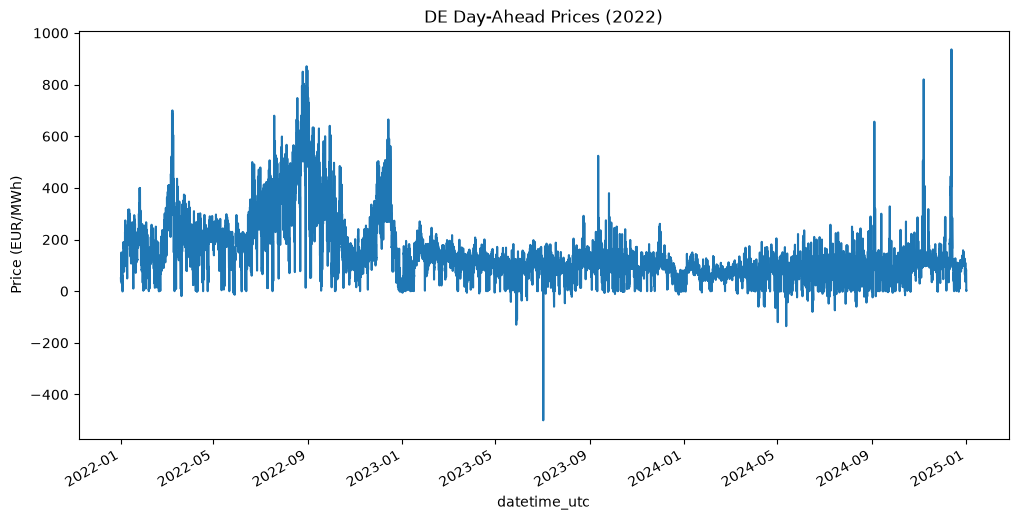

In [10]:
df['price_eur_mwh'].plot(figsize=(12, 6), title="DE Day-Ahead Prices (2022)", ylabel="Price (EUR/MWh)") 

In [11]:
#check timestamp continuity
df.index.is_monotonic_increasing

True

In [12]:
df.index.to_series().diff().value_counts()

datetime_utc
0 days 01:00:00    26298
0 days 02:00:00        3
Name: count, dtype: int64

the three days with 2 hours difference is due to the DST changes, hence the time contintuity is maintainted.

In [15]:
df[df['price_eur_mwh'] < 0].describe()

,price_eur_mwh
count,826.000000
mean,-11.223462
std,31.010306
min,-500.000000
25%,-9.950000
50%,-1.625000
75%,-0.090000
max,-0.010000
